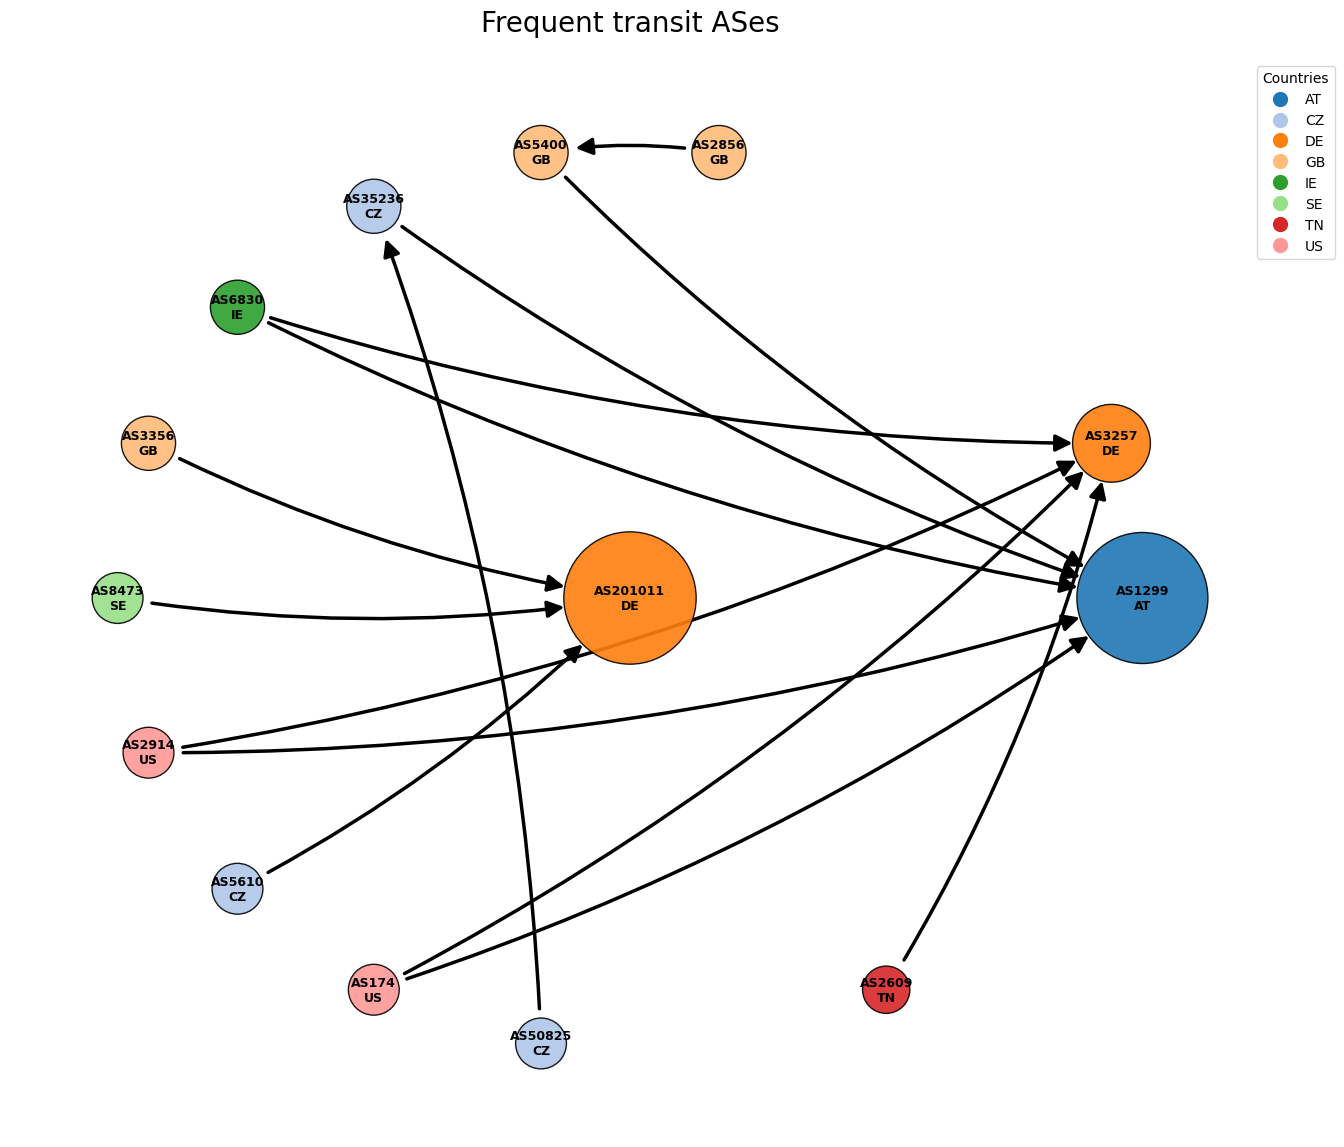

In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib.lines import Line2D
import numpy as np

# 1. Load and clean the dataset
df = pd.read_csv('all_hops.csv')
df.columns = df.columns.str.strip()
df = df.dropna(subset=['asn'])
df['asn'] = df['asn'].astype(int)

# 2. Extract AS-level paths
paths = []
for prb_id, group in df.sort_values(['prb_id', 'hop']).groupby('prb_id'):
    asn_list = group['asn'].tolist()
    collapsed = []
    if asn_list:
        collapsed.append(asn_list[0])
        for x in asn_list[1:]:
            if x != collapsed[-1]:
                collapsed.append(x)
    paths.append(collapsed)

# 3. Frequency Statistics & Selection
global_counts = Counter([asn for path in paths for asn in path])
top_30_asns = [asn for asn, count in global_counts.most_common(20)[1:]]
top_set = set(top_30_asns)

# Identify the biggest ASN for the center
biggest_asn = top_30_asns[0]
remaining_asns = top_30_asns[1:]

# 4. Build the Directed Graph
G = nx.DiGraph()
for path in paths:
    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        if u in top_set and v in top_set:
            if G.has_edge(u, v):
                G[u][v]['weight'] += 1
            else:
                G.add_edge(u, v, weight=1)

# 5. Map AS to Country
asn_country_map = df.groupby('asn')['country'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else '??'
).to_dict()

# 6. Preparation for Visualization
plt.figure(figsize=(16, 14))

# Manual position calculation: Biggest in center, others in circle
pos = {}
pos[biggest_asn] = np.array([0, 0])
angles = np.linspace(0, 2 * np.pi, len(remaining_asns), endpoint=False)
for i, asn in enumerate(remaining_asns):
    pos[asn] = np.array([np.cos(angles[i]), np.sin(angles[i])])

node_list = list(G.nodes())
node_sizes_list = [global_counts[n] * 180 + 800 for n in node_list]

unique_countries = sorted(list(set([asn_country_map[n] for n in G.nodes()])))
cmap = plt.get_cmap('tab20')
country_color_map = {c: cmap(i % 20 / 20) for i, c in enumerate(unique_countries)}
node_colors = [country_color_map[asn_country_map[n]] for n in node_list]

# 7. Drawing
# Nodes
nx.draw_networkx_nodes(G, pos, 
                       node_size=node_sizes_list, 
                       node_color=node_colors, 
                       alpha=0.9, 
                       edgecolors='black')

# Edges
nx.draw_networkx_edges(
    G, pos, 
    width=2.5,           # <--- CHANGE THIS NUMBER to adjust fixed thickness
    alpha=1.0,           # Solid colour (no transparency)
    edge_color='black',  # Solid black arrows
    arrowsize=25,        # Size of the arrowhead
    connectionstyle="arc3,rad=0.08", 
    node_size=node_sizes_list,
    min_source_margin=25,
    min_target_margin=25
)

# Labels
labels = {n: f"AS{n}\n{asn_country_map.get(n, '??')}" for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight='bold')

# 8. Legend and Title
legend_elements = [Line2D([0], [0], marker='o', color='w', label=c,
                          markerfacecolor=country_color_map[c], markersize=12) for c in unique_countries]
plt.legend(handles=legend_elements, title="Countries", loc='upper left', bbox_to_anchor=(1, 1))

plt.title(f"Frequent transit ASes", fontsize=20, pad=20)
plt.axis('off')

# 9. Save and Show
plt.savefig('frequent_transit_ases.png', bbox_inches='tight', dpi=300)
plt.show()